# 末端笛卡尔直线插补:仿真与实机控制

让机械臂的 DH 末端帧沿一条笛卡尔直线从起点平滑运动到终点。

主要步骤:

1. 用当前标准 DH 表组装 RTB 的 `DHRobot`(`dfarm`)。
2. 调 `rtb.tools.trajectory.ctraj` 在起止位姿之间插出 N 段笛卡尔直线轨迹。
3. 对每个轨迹点用 `ikine_LM` 求逆解,前一点的解作为下一点的初值,以保证关节连续性。
4. 用 `dfarm.plot(..., movie=...)` 把动画保存成 gif。
5. 仿真无误后,打开 `execute_on_hardware = True` 把同一组关节序列下发到一体化关节。

起点固定为安全竖直 **park** 姿态 `[0, 90, 0, 0, 0, 0]` 的末端坐标 `(0, 21.94, 368) mm`;终点 `path_end_mm` 默认为 `(250, 21.94, 250) mm`,**可任意修改** —— J1(底座 yaw)由 IK 自由决定,改不同的终点即可换轨迹形状。中间帧 z 全程 ≥ 0,过桌面保护;若想 J1 不转,只需把终点也放在 y=21.94 mm 平面内。

注意:这里的坐标是 DH 末端帧原点(不一定等于夹爪 TCP)。

轨迹点数            : 40
起点目标 mm         : [0, 21.94, 368]
终点目标 mm         : [100, 200, 200]
起点关节角 deg      : [2.2, 90.563, -2.838, 7.364, 4.127, -165.786]
终点关节角 deg      : [57.425, 80.86, -79.583, 51.865, 17.179, -165.786]
每关节最小值 deg    : [2.2, 80.86, -81.437, 7.364, 4.127, -165.786]
每关节最大值 deg    : [57.425, 102.488, -2.838, 56.476, 21.264, -165.786]
IK 位置残差最大 mm  : 0.6364503002229512   (相对 ctraj 实际目标点,反映 IK 收敛精度)
首末 FK 坐标 mm     :
  start: [-0.034, 22.04, 367.817]
  end  : [100.0, 200.0, 200.0]


,J1,J2,J3,J4,J5,J6
0,2.200,90.563,-2.838,7.364,4.127,-165.786
1,4.063,90.852,-3.982,10.196,7.219,-165.786
2,10.922,92.360,-9.804,20.951,13.361,-165.786
3,14.469,93.038,-12.434,24.675,15.941,-165.786
4,20.406,94.259,-16.871,30.070,18.749,-165.786
5,26.016,95.449,-21.243,34.376,20.422,-165.786
6,31.063,96.577,-25.547,37.926,21.181,-165.786
7,35.441,97.632,-29.795,40.941,21.264,-165.786
8,39.151,98.614,-34.008,43.564,20.890,-165.786
9,42.249,99.519,-38.196,45.881,20.238,-165.786


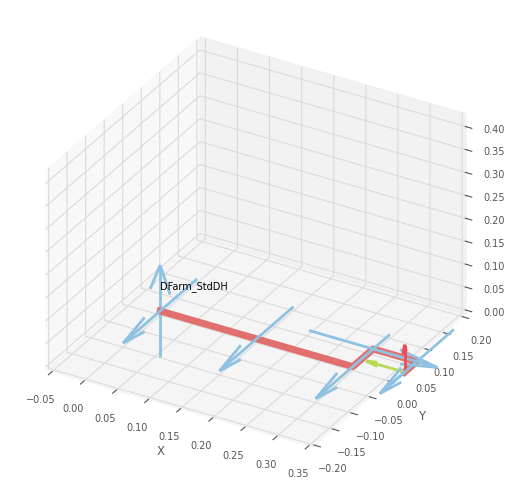

动画文件已保存(含预期直线标注): cartesian_line_anim.gif


<Figure size 640x480 with 0 Axes>

In [ ]:
# ---- 把存放 arm_robot.py 的目录加入 sys.path,使 import 可达 -----------------
import os, sys
_search_root = os.path.abspath(os.getcwd())
for _ in range(5):
    if os.path.isfile(os.path.join(_search_root, 'arm_robot.py')):
        if _search_root not in sys.path:
            sys.path.insert(0, _search_root)
        break
    _search_root = os.path.dirname(_search_root)
else:
    raise ImportError('未在最近 5 层父目录中定位到 arm_robot.py;请在 daran/ 或其子目录下打开本笔记本')
# ----------------------------------------------------------------------------
import time
import numpy as np
import roboticstoolbox as rtb
from roboticstoolbox import DHRobot, RevoluteDH
from spatialmath import SE3
import arm_robot as robot

np.set_printoptions(precision=4, suppress=True)

# ============================================================
# 1) 直线轨迹参数
# ============================================================
# DH 末端帧原点的起止笛卡尔点(mm)。改 path_end_mm 即可换轨迹;J1 由 IK 自由决定,
# 如果想保持 J1 不转,把终点也放在 y=path_start_mm[1] 平面内(此处默认仍然共面)。
path_start_mm  = [0,   21.94, 368]   # 安全竖直 park 姿态 [0,90,0,0,0,0] 的末端 FK 坐标
path_end_mm    = [100, 200, 200]   # 任意可达点皆可;改 y/x/z 即换轨迹形状,IK 会自动重新求解
waypoint_count = 40

# 是否仅约束位置(忽略起止位姿的 R/P/Y)
ignore_orientation   = True
start_orient_rpy_deg = [0, 0, 0]
end_orient_rpy_deg   = [0, 0, 0]
euler_convention     = 'zyx'

# 反解的初值(度)。建议尽量接近机械臂当前姿态,减少首点跳变。
ik_seed_deg = [0, 90, 0, 0, 0, 0]   # 用 park 姿态做种子,IK 自由决定 J1;尽量贴近实机当前姿态以减少首点跳变

# 关节模型角范围(度)
qmin_deg = [-160, -40, -160, -160, -180, -180]
qmax_deg = [ 160, 180,  160,  160,  180,  180]

# 桌面保护:所有 DH 中间坐标系原点的 z 必须 >= desk_z_min_m (m)
desk_z_min_m = 0.0

# 动画输出
animation_filename = 'cartesian_line_anim.gif'
plot_box           = [-0.05, 0.35, -0.20, 0.20, 0.00, 0.42]

# 实机控制
execute_on_hardware = True
can_bridge_port     = '/dev/ttyACM1'
serial_baud         = 115200

# 'tracking': 连续发送 mode=0 跟踪;适合小步长直线
# 'point'   : 每点用 mode=1 梯形轨迹到位;只在测试单点时用
runtime_mode      = 'tracking'
cmd_period_s      = 0.2
joint_speed_rpm   = 2.0
joint_accel_rpm_s = 10.0

# 实机运行时的位姿验证(仿真 cmd vs 实测关节角):
#   - verify_period_s      采样间隔(秒);避免每次循环都走 read_joints,会拖慢命令下发
#   - verify_threshold_deg 单关节误差超过该值时,打印 WARN 并标出问题关节
#   - verify_log_path      None 时自动按时间戳生成 pose_verify_*.csv,便于回溯
verify_enabled       = True
verify_period_s      = 0.3
verify_threshold_deg = 5.0
verify_log_path      = None


# ============================================================
# 2) 模型 / 限位检查 / 位姿构造
# ============================================================
LINK_PARAMS = (
    dict(alpha=np.pi/2),
    dict(a=0.15),
    dict(a=0.15),
    dict(d=-0.05494, alpha=np.pi/2, offset=np.pi/2),
    dict(d=0.068,    alpha=-np.pi/2),
    dict(d=0.033),
)


def make_dfarm():
    links = [
        RevoluteDH(qlim=np.deg2rad([qmin_deg[i], qmax_deg[i]]), **kw)
        for i, kw in enumerate(LINK_PARAMS)
    ]
    return DHRobot(links, name='DFarm_StdDH')


def verify_within_limits(angles_deg):
    arr = np.asarray(angles_deg, dtype=float)
    lo  = np.asarray(qmin_deg,    dtype=float)
    hi  = np.asarray(qmax_deg,    dtype=float)
    bad = np.flatnonzero((arr < lo) | (arr > hi))
    if bad.size:
        msg = '; '.join(
            f'J{i+1}: {arr[i]:+.2f}° not in [{lo[i]:+.2f}, {hi[i]:+.2f}]'
            for i in bad
        )
        raise ValueError('关节模型角越界 -> ' + msg)


def target_pose_se3(xyz_mm, rpy_deg):
    pose = SE3.Trans(np.asarray(xyz_mm, dtype=float) * 1e-3)
    if not ignore_orientation:
        pose = pose * SE3.RPY(rpy_deg, unit='deg', order=euler_convention)
    return pose


def verify_above_desk(q_rad, dfarm, z_min=None):
    """桌面保护:所有 DH 中间坐标系原点的 z 必须 >= z_min(m)。"""
    if z_min is None:
        z_min = desk_z_min_m
    frames = dfarm.fkine_all(q_rad)
    below = [(i, float(frames[i].t[2]))
             for i in range(1, len(frames))
             if float(frames[i].t[2]) < z_min - 1e-9]
    if below:
        detail = '; '.join(f'F{i}: z={z*1000:+.1f}mm' for i, z in below)
        raise ValueError(
            f'存在关节坐标系 z 低于桌面安全线 (< {z_min*1000:+.0f} mm) -> '
            + detail
        )


# ============================================================
# 3) 生成轨迹
# ============================================================
dfarm        = make_dfarm()
T_start_pose = target_pose_se3(path_start_mm, start_orient_rpy_deg)
T_end_pose   = target_pose_se3(path_end_mm,   end_orient_rpy_deg)

cartesian_path = rtb.tools.trajectory.ctraj(T_start_pose, T_end_pose, waypoint_count)
dof_mask = [1, 1, 1, 0, 0, 0] if ignore_orientation else [1] * 6

# 6-DOF IK
joint_solutions = []
seed = np.deg2rad(np.asarray(ik_seed_deg, dtype=float))
for idx, T_step in enumerate(cartesian_path):
    ik = dfarm.ikine_LM(
        T_step, q0=seed, mask=dof_mask,
        ilimit=200, slimit=200, joint_limits=True,
    )
    if not ik.success:
        raise RuntimeError(
            f'第 {idx} 个轨迹点反解失败: '
            f'{getattr(ik, "reason", "")}; residual={getattr(ik, "residual", None)}'
        )
    seed = ik.q
    joint_solutions.append(ik.q)

joint_path     = np.asarray(joint_solutions)
joint_path_deg = np.rad2deg(joint_path)
verify_within_limits(joint_path_deg.min(axis=0))
verify_within_limits(joint_path_deg.max(axis=0))

# 桌面保护:扫一遍整条轨迹的每个采样点
for _k, _q in enumerate(joint_path):
    verify_above_desk(_q, dfarm)

# 两套位置参考:
#   - cartesian_target_mm : ctraj 实际下发到 IK 的目标点(五次时间标定,起止平滑)
#   - nominal_xyz_mm      : 起止之间的 *匀速直线* 采样,只用于在 3D 图里画那条期望红线
# IK 误差以 ctraj 目标为基准,反映反解收敛精度;与 ctraj 时间标定无关。
realized_xyz_mm     = np.asarray([dfarm.fkine(q).t * 1000 for q in joint_path])
cartesian_target_mm = np.asarray([np.asarray(T.t) * 1000 for T in cartesian_path])
nominal_xyz_mm      = np.linspace(path_start_mm, path_end_mm, waypoint_count)
ik_residual_mm      = realized_xyz_mm - cartesian_target_mm

print('轨迹点数            :', waypoint_count)
print('起点目标 mm         :', path_start_mm)
print('终点目标 mm         :', path_end_mm)
print('起点关节角 deg      :', np.round(joint_path_deg[0],  3).tolist())
print('终点关节角 deg      :', np.round(joint_path_deg[-1], 3).tolist())
print('每关节最小值 deg    :', np.round(joint_path_deg.min(axis=0), 3).tolist())
print('每关节最大值 deg    :', np.round(joint_path_deg.max(axis=0), 3).tolist())
print('IK 位置残差最大 mm  :', float(np.max(np.linalg.norm(ik_residual_mm, axis=1))),
      '  (相对 ctraj 实际目标点,反映 IK 收敛精度)')
print('首末 FK 坐标 mm     :')
print('  start:', np.round(realized_xyz_mm[0],  3).tolist())
print('  end  :', np.round(realized_xyz_mm[-1], 3).tolist())

# 表格化关节角(Jupyter 内显示;脚本/无显示环境会 fallback 到 numpy 输出)
try:
    import pandas as pd
    display(pd.DataFrame(joint_path_deg, columns=[f'J{i}' for i in range(1, 7)]).round(3))
except Exception:
    print(np.round(joint_path_deg, 3))

# 自定义动画循环:先把预期直线、起点、终点标注在 3D 坐标系上,
# 再逐帧捕获机械臂姿态。这样 gif 里就能直观看到末端是否沿红线运行。
from roboticstoolbox.backends.PyPlot import PyPlot

env = PyPlot()
env.launch(name='Cartesian Line', limits=plot_box)
env.add(dfarm)

expected_xyz_m = nominal_xyz_mm / 1000.0
env.ax.plot(
    expected_xyz_m[:, 0], expected_xyz_m[:, 1], expected_xyz_m[:, 2],
    color='red', linewidth=2.5, linestyle='-', alpha=0.9,
    label='expected line',
)
env.ax.scatter(
    [expected_xyz_m[0, 0]], [expected_xyz_m[0, 1]], [expected_xyz_m[0, 2]],
    color='limegreen', s=80, marker='o', label='start',
)
env.ax.scatter(
    [expected_xyz_m[-1, 0]], [expected_xyz_m[-1, 1]], [expected_xyz_m[-1, 2]],
    color='magenta', s=80, marker='X', label='end',
)
env.ax.legend(loc='upper left', fontsize=8)

frames = []
for q in joint_path:
    dfarm.q = q
    env.step(0.05)
    frames.append(env.getframe())

# loop=0 表示 gif 无限循环;duration 单位是 ms
frames[0].save(
    animation_filename,
    save_all=True,
    append_images=frames[1:],
    optimize=False,
    duration=80,
    loop=0,
)
print('动画文件已保存(含预期直线标注):', animation_filename)

## 实机执行

确认上方动画与关节角范围合理后,把 `execute_on_hardware` 改成 True,再运行下一段。

In [19]:
import csv
from datetime import datetime


def query_joint_state(arm):
    raw = arm.read_joints()
    if raw is False:
        return False, False
    return raw, arm.servo_to_model(raw)


if not execute_on_hardware:
    print('execute_on_hardware = False,未发送实机命令。'
          '确认动画和关节角后改成 True 再运行。')
else:
    verify_within_limits(joint_path_deg.min(axis=0))
    verify_within_limits(joint_path_deg.max(axis=0))

    arm = robot.arm_robot(
        L_p             = 0,
        L_p_mass_center = 0,
        MAX_list_temp   = qmax_deg,
        MIN_list_temp   = qmin_deg,
        G_p             = 0,
        com             = can_bridge_port,
        uart_baudrate   = serial_baud,
    )

    raw_before, model_before = query_joint_state(arm)
    print('运动前 model =', model_before)
    if model_before is False:
        raise RuntimeError('读取当前关节角失败,中止运动。')
    print(f'[yaw ] 运动前: J1 act = {model_before[0]:+7.3f}° '
          f'(park 起点 IK 解的 J1 ≈ {joint_path_deg[0, 0]:+.3f}°,这是 cmd 起始值)',
          flush=True)

    # 先把机械臂运动到轨迹起点
    print('先运动到轨迹起点:', np.round(joint_path_deg[0], 3).tolist())
    if arm.set_arm_joints(angle_list=joint_path_deg[0].tolist(),
                          speed=joint_speed_rpm) is False:
        raise RuntimeError('运动到起点失败。')
    arm.pose_done()
    time.sleep(0.5)

    # ------------------------------------------------------------------
    # 位姿验证:固定频率读一次实测关节角,与上一帧 cmd 对比;超阈值告警 + 写 CSV
    # ------------------------------------------------------------------
    verify_log_file   = None
    verify_csv_writer = None
    verify_last_t     = [None]          # 列表持有可变状态,免去 nonlocal
    verify_log_name   = None
    verify_stats      = {'samples': 0, 'over': 0, 'read_fail': 0,
                         'max_abs_err_deg': 0.0, 'worst_joint': None,
                         'j1_act_abs_max': 0.0, 'j1_err_abs_max': 0.0}

    if verify_enabled:
        verify_log_name = (verify_log_path
                           or f'pose_verify_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv')
        verify_log_file = open(verify_log_name, 'w', newline='', encoding='utf-8')
        verify_csv_writer = csv.writer(verify_log_file)
        header = ['t_s', 'waypoint_idx']
        for _i in range(1, 7):
            header += [f'J{_i}_cmd_deg', f'J{_i}_act_deg', f'J{_i}_err_deg']
        header += ['max_abs_err_deg', 'over_threshold']
        verify_csv_writer.writerow(header)
        print(f'[verify] 启用:阈值 {verify_threshold_deg}° / '
              f'采样间隔 {verify_period_s}s / 日志 {verify_log_name}')

    def _maybe_verify(t_now, idx, q_cmd_deg, force=False):
        """以 verify_period_s 为节流,读实测并和给定 cmd 做对比;force=True 时无视节流。"""
        if not verify_enabled:
            return
        if (not force
                and verify_last_t[0] is not None
                and (t_now - verify_last_t[0]) < verify_period_s):
            return
        verify_last_t[0] = t_now

        _, model_now = query_joint_state(arm)
        if model_now is False:
            verify_stats['read_fail'] += 1
            print(f'[verify] idx={idx} t={t_now:.2f}s 读取关节角失败,跳过本次对比')
            return

        cmd = np.asarray(q_cmd_deg, dtype=float)
        act = np.asarray(model_now,  dtype=float)
        err = act - cmd
        max_err = float(np.max(np.abs(err)))
        over    = max_err > verify_threshold_deg

        verify_stats['samples'] += 1
        if max_err > verify_stats['max_abs_err_deg']:
            verify_stats['max_abs_err_deg'] = max_err
            verify_stats['worst_joint']     = int(np.argmax(np.abs(err))) + 1
        if abs(act[0]) > verify_stats['j1_act_abs_max']:
            verify_stats['j1_act_abs_max'] = abs(act[0])
        if abs(err[0]) > verify_stats['j1_err_abs_max']:
            verify_stats['j1_err_abs_max'] = abs(err[0])

        # 实时反馈:底座 J1 单独一行,便于一眼判断电机是否真的不动
        print(f'[yaw ] idx={idx:>3} t={t_now:6.2f}s  '
              f'J1 cmd={cmd[0]:+7.3f}°  act={act[0]:+7.3f}°  err={err[0]:+7.3f}°',
              flush=True)

        row = [f'{t_now:.3f}', idx]
        for _i in range(6):
            row += [f'{cmd[_i]:.3f}', f'{act[_i]:.3f}', f'{err[_i]:+.3f}']
        row += [f'{max_err:.3f}', int(over)]
        verify_csv_writer.writerow(row)
        verify_log_file.flush()

        if over:
            verify_stats['over'] += 1
            bad = [(j, err[j-1]) for j in range(1, 7)
                   if abs(err[j-1]) > verify_threshold_deg]
            detail = '; '.join(
                f'J{j}: cmd={cmd[j-1]:+.2f}° act={act[j-1]:+.2f}° err={e:+.2f}°'
                for j, e in bad
            )
            print(f'[verify WARN] idx={idx} t={t_now:.2f}s 超阈值 -> {detail}')

    try:
        t_loop_start = time.time()
        # 进入循环前最后一次"已下发"的 cmd 是起点位姿,前一帧对比用得到
        last_q_cmd = joint_path_deg[0].tolist()

        if runtime_mode == 'tracking':
            # mode=0 时 param 是输入滤波带宽,需 < 300,设为发送频率的一半
            filter_bw = min(250, max(1, 1.0 / (2.0 * cmd_period_s)))
            print(f'tracking 模式: cmd_period={cmd_period_s} s, filter_bw={filter_bw}')
            for idx, q_deg_step in enumerate(joint_path_deg):
                # 在发新命令之前,先看上一帧的跟踪情况(已有 cmd_period_s 的反应时间)
                _maybe_verify(time.time() - t_loop_start, idx, last_q_cmd)
                servo_cmd = arm.model_to_servo(q_deg_step.tolist())
                arm.set_angles(arm.ID_list, servo_cmd,
                               speed=20, param=filter_bw, mode=0)
                last_q_cmd = q_deg_step.tolist()
                time.sleep(cmd_period_s)
        elif runtime_mode == 'point':
            print('point 模式 (逐点梯形)')
            for idx, q_deg_step in enumerate(joint_path_deg):
                _maybe_verify(time.time() - t_loop_start, idx, last_q_cmd)
                servo_cmd = arm.model_to_servo(q_deg_step.tolist())
                arm.set_angles(arm.ID_list, servo_cmd,
                               speed=joint_speed_rpm, param=joint_accel_rpm_s, mode=1)
                last_q_cmd = q_deg_step.tolist()
                time.sleep(cmd_period_s)
        else:
            raise ValueError("runtime_mode 只能取 'tracking' 或 'point'")

        time.sleep(0.5)
        # 终态:强制再比一次最后一帧 cmd vs 实测(稳态误差)
        _maybe_verify(time.time() - t_loop_start,
                      len(joint_path_deg) - 1, last_q_cmd, force=True)

        raw_after, model_after = query_joint_state(arm)
        print('运动后 model =', model_after)
        if model_after is not False:
            print(f'[yaw ] 运动后: J1 act = {model_after[0]:+7.3f}° '
                  f'(对应 cmd ≈ {joint_path_deg[-1, 0]:+.3f}°,差值即终态稳态误差)',
                  flush=True)
            T_done = dfarm.fkine(np.deg2rad(model_after))
            print('回读模型角对应的 FK 末端 mm =',
                  np.round(T_done.t * 1000, 3).tolist())
    finally:
        if verify_log_file is not None:
            verify_log_file.close()
            if verify_stats['samples'] == 0:
                print(f'[verify] 已关闭日志:无有效样本(可能 verify_period_s 过大)。'
                      f' 文件: {verify_log_name}')
            else:
                worst = verify_stats['worst_joint']
                print(
                    f'[verify] 汇总:样本 {verify_stats["samples"]} 帧'
                    f' / 超阈值 {verify_stats["over"]}'
                    f' / 读取失败 {verify_stats["read_fail"]};'
                    f' 全程最大 |err| = {verify_stats["max_abs_err_deg"]:.2f}°'
                    + (f' (J{worst})' if worst else '')
                    + f';日志: {verify_log_name}'
                )
                print(
                    f'[yaw ] 汇总:J1 全程 |act| 最大 = '
                    f'{verify_stats["j1_act_abs_max"]:.3f}°,'
                    f' |err| 最大 = {verify_stats["j1_err_abs_max"]:.3f}°'
                    f' (cmd 由 IK 决定;|err| 反映 J1 的跟踪误差,'
                    f'cmd 范围见 "每关节最小/最大值")'
                )


位置增益 P：10.0
积分增益 I：5.0
转速增益 D：0.550000011920929
机械臂第  1  号关节的 PID 修改为： [10.0, 5.0, 0.550000011920929]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  2  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  3  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.0
积分增益 I：9.0
转速增益 D：0.5
机械臂第  4  号关节的 PID 修改为： [10.0, 9.0, 0.5]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.10000000149011612
机械臂第  5  号关节的 PID 修改为： [12.0, 5.0, 0.10000000149011612]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.09600000083446503
机械臂第  6  号关节的 PID 修改为： [12.0, 5.0, 0.09600000083446503]
一体化关节输出轴当前角度不在[0, 0]范围内，运行过程中软件限位范围设置失败！
初始化成功
运动前 model = [-0.0, 90.0, 0.0, -0.0, -0.0, 0.0]
[yaw ] 运动前: J1 act =  -0.000° (park 起点 IK 解的 J1 ≈ -3.814°,这是 cmd 起始值)
先运动到轨迹起点: [-3.814, 89.541, 1.566, -1.318, -0.001, 0.0]
[verify] 启用:阈值 5.0° / 采样间隔 0.3s / 日志 pose_verify_20260514_161006.csv
tracking

SystemExit: 

/home/wpy/anaconda3/envs/DC_robot/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 可选:回到关节零位

把 `request_home = True` 后运行下面 cell,机械臂会运动到安全 park 姿态 [0, 90, 0, 0, 0, 0]
(J2=+90°,臂体竖直向上,所有连杆原点均在 z≥0)。

In [26]:
request_home  = True
home_pose_deg = [0, 90, 0, 0, 0, 0]   # 安全 park 姿态,J2=+90° 让臂体竖直向上

if not request_home:
    print('request_home = False,未发送回零命令。')
else:
    target = np.asarray(home_pose_deg, dtype=float)
    verify_within_limits(target)
    arm = robot.arm_robot(
        L_p             = 0,
        L_p_mass_center = 0,
        MAX_list_temp   = qmax_deg,
        MIN_list_temp   = qmin_deg,
        G_p             = 0,
        com             = can_bridge_port,
        uart_baudrate   = serial_baud,
    )
    print('运动前 model =', query_joint_state(arm)[1])
    sent_ok = arm.set_arm_joints(angle_list=target.tolist(), speed=joint_speed_rpm)
    print('指令下发结果 =', sent_ok)
    arm.pose_done()
    time.sleep(0.5)
    print('运动后 model =', query_joint_state(arm)[1])

位置增益 P：10.0
积分增益 I：5.0
转速增益 D：0.550000011920929
机械臂第  1  号关节的 PID 修改为： [10.0, 5.0, 0.550000011920929]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  2  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  3  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.0
积分增益 I：9.0
转速增益 D：0.5
机械臂第  4  号关节的 PID 修改为： [10.0, 9.0, 0.5]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.10000000149011612
机械臂第  5  号关节的 PID 修改为： [12.0, 5.0, 0.10000000149011612]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.09600000083446503
机械臂第  6  号关节的 PID 修改为： [12.0, 5.0, 0.09600000083446503]
一体化关节输出轴当前角度不在[0, 0]范围内，运行过程中软件限位范围设置失败！
初始化成功
运动前 model = [4.3, 86.0, -0.7, 4.9, -1.0, 9.0]
指令下发结果 = True
运动后 model = [0.0, 90.0, 0.0, 0.0, -0.0, -0.0]
